In [12]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
import torch
from torch.export.pt2_archive.constants import MODELS_DIR

# Data
X, y = make_classification(n_samples=5000, n_features=20, n_classes=4, n_informative = 4, random_state=42)
X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.long)
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, stratify=y, test_size=0.2)

# Network Architecure, Training Functions and Scikit Wrapper

In [13]:
from torch import nn
from typing import Literal

class MLPClassifier(nn.Module):
    def __init__(self, n_hidden:int, hidden_dim:int, input_dim:int, output_dim:int, activation:Literal['ReLU', 'Tanh'] = 'ReLU'):
        super(MLPClassifier, self).__init__()
        self.input_layer = nn.Linear(input_dim, hidden_dim)
        self.hidden_layers = nn.ModuleList([nn.Linear(hidden_dim, hidden_dim) for _ in range(n_hidden)])
        self.output_layer = nn.Linear(hidden_dim, output_dim)

        if activation == 'ReLU':
            self.activation = nn.ReLU()
        elif activation == 'Tanh':
            self.activation = nn.Tanh()
        else:
            raise ValueError(f"Unknown activation function: {activation}")

    def forward(self, input):
        x = self.activation(self.input_layer(input))
        for layer in self.hidden_layers:
            x = self.activation(layer(x))
        x = self.output_layer(x)

        return x.squeeze(1) if x.shape[-1] == 1 else x

In [4]:
from torch.utils.data import TensorDataset, DataLoader, Subset
from torch.nn.utils import clip_grad_norm_

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def get_train_loaders(dataset:TensorDataset, train_idx, val_idx, batch_size:int=256, shuffle:bool=True):
    train_loader = DataLoader(Subset(dataset, train_idx), batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(Subset(dataset, val_idx), batch_size=batch_size)

    return train_loader, val_loader


def _train_one_epoch(model, loader, optimizer, criterion, max_norm:float=1.0):
    model.train()
    running_loss = 0.0
    for X, y in loader:
        X, y = X.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(X), y)
        running_loss += loss.item()
        loss.backward()
        clip_grad_norm_(model.parameters(), max_norm=max_norm)
        optimizer.step()
    avg_loss = running_loss / len(loader)

    return avg_loss

def _calculate_val_loss(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    with torch.no_grad():
        for X,y in loader:
            X, y = X.to(DEVICE), y.to(DEVICE)
            output = model(X)
            loss = criterion(output, y)
            running_loss += loss.item()
    avg_loss = running_loss / len(loader)

    return avg_loss

In [16]:
import numpy as np
from torch.nn.utils import clip_grad_norm_
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.utils.validation import check_is_fitted
from sklearn.metrics import accuracy_score

class MyWrapper(ClassifierMixin, BaseEstimator):
    def __init__(self, model, classes:list | np.ndarray, lr:float=1e-3, epochs:int=50, batch_size:int=None, device:torch.device=None, is_fitted:bool = False):
        if device is None:
            self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        else:
            self.device = device

        self.model = model.to(self.device)
        self.classes = classes
        self.classes_ = classes

        self.batch_size = batch_size
        self.epochs = epochs
        self.lr = lr
        self.is_fitted  = is_fitted


    def fit(self, X: np.ndarray, y: np.ndarray, sample_weight=None) -> float:
        def _train_one_epoch(model, loader, optimizer, criterion, max_norm:float=1.0):
            model.train()
            running_loss = 0.0
            for X, y in loader:
                X, y = X.to(self.device), y.to(self.device)
                optimizer.zero_grad()
                loss = criterion(model(X), y)
                running_loss += loss.item()
                loss.backward()
                clip_grad_norm_(model.parameters(), max_norm=max_norm)
                optimizer.step()
            avg_loss = running_loss / len(loader)

            return avg_loss

        self.model.to(self.device)
        optimzer = torch.optim.Adam(self.model.parameters(), lr=self.lr)

        if len(self.classes) == 2:
            criterion = nn.BCEWithLogitsLoss()
            y_tensor = torch.Tensor(y).to(self.device)

        else:
            criterion = nn.CrossEntropyLoss()
            y_tensor = torch.Tensor(y).long().to(self.device)

        X_tensor = torch.Tensor(X).to(self.device)

        if sample_weight is not None:
            sampler = WeightedRandomSampler(sample_weight, len(X_tensor), replacement=True)
        else:
            sampler = None

        train_loader = DataLoader(TensorDataset(X_tensor, y_tensor), batch_size=self.batch_size, sampler=sampler)

        running_loss = 0.0
        for epoch in range(self.epochs):
            running_loss += _train_one_epoch(self.model, train_loader, optimzer, criterion)

        print(f'Avrage Loss {running_loss/self.epochs}')

        self.is_fitted = True
        return self


    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        X_tensor = torch.Tensor(X).to(self.device)

        self.model.eval()
        output = self.model(X_tensor)

        if len(self.classes) == 2:
            proba = torch.sigmoid(output).detach().cpu().numpy()
            proba = proba.reshape(-1, 1)
            proba = np.hstack([1 - proba, proba])
        else:
            proba = torch.softmax(output, dim=1).detach().cpu().numpy()


        return proba

    def predict(self, X: np.ndarray) -> np.ndarray:
        proba = self.predict_proba(X)

        if len(self.classes) == 2:
            preds = self.classes[(proba[:, 1] >= 0.5).astype(int)]
        else:
            preds = self.classes[proba.argmax(axis=1)]

        return preds


    def score(self, X, y, sample_weight=None):
        check_is_fitted(self, attributes=["is_fitted"])
        y_pred = self.predict(X)

        return accuracy_score(y, y_pred, sample_weight=sample_weight)


# Training


 ===================== Training Fold 0  ===================== 

Saved new best model to Models/Classifier/fold_0.pth, with new best_val_loss=1.3622119426727295
Saved new best model to Models/Classifier/fold_0.pth, with new best_val_loss=1.293159157037735
Saved new best model to Models/Classifier/fold_0.pth, with new best_val_loss=1.161894053220749
Saved new best model to Models/Classifier/fold_0.pth, with new best_val_loss=1.0234216004610062
Saved new best model to Models/Classifier/fold_0.pth, with new best_val_loss=0.9328633248806
Saved new best model to Models/Classifier/fold_0.pth, with new best_val_loss=0.8589708060026169
Saved new best model to Models/Classifier/fold_0.pth, with new best_val_loss=0.801789864897728
Saved new best model to Models/Classifier/fold_0.pth, with new best_val_loss=0.766348198056221
Saved new best model to Models/Classifier/fold_0.pth, with new best_val_loss=0.7241039723157883
Saved new best model to Models/Classifier/fold_0.pth, with new best_val_loss=0

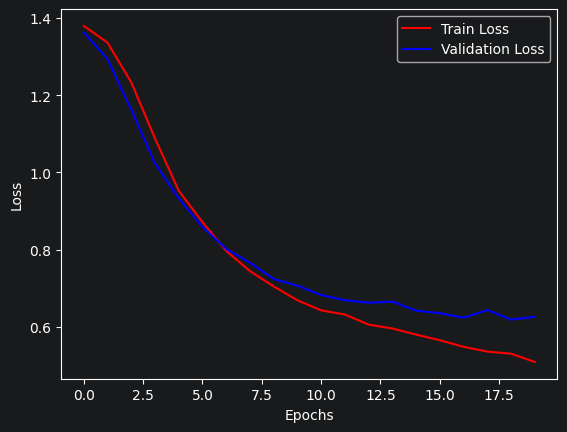


 ===================== Training Fold 1  ===================== 

Saved new best model to Models/Classifier/fold_1.pth, with new best_val_loss=1.3643316328525543
Saved new best model to Models/Classifier/fold_1.pth, with new best_val_loss=1.2783935368061066
Saved new best model to Models/Classifier/fold_1.pth, with new best_val_loss=1.1472165882587433
Saved new best model to Models/Classifier/fold_1.pth, with new best_val_loss=1.027734637260437
Saved new best model to Models/Classifier/fold_1.pth, with new best_val_loss=0.9312597364187241
Saved new best model to Models/Classifier/fold_1.pth, with new best_val_loss=0.9028255343437195
Saved new best model to Models/Classifier/fold_1.pth, with new best_val_loss=0.8504329472780228
Saved new best model to Models/Classifier/fold_1.pth, with new best_val_loss=0.8498886525630951
Saved new best model to Models/Classifier/fold_1.pth, with new best_val_loss=0.8361421227455139
Saved new best model to Models/Classifier/fold_1.pth, with new best_val_

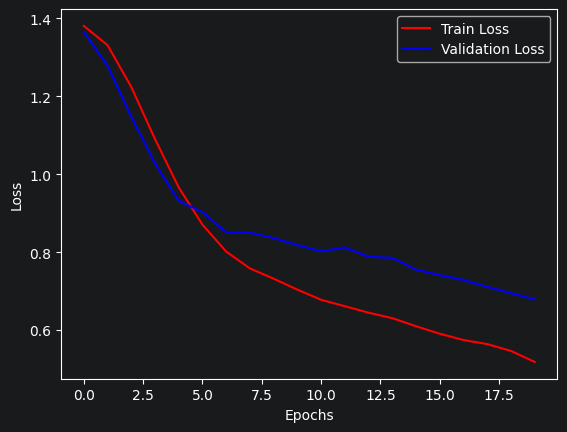


 ===================== Training Fold 2  ===================== 

Saved new best model to Models/Classifier/fold_2.pth, with new best_val_loss=1.3637960255146027
Saved new best model to Models/Classifier/fold_2.pth, with new best_val_loss=1.2730357944965363
Saved new best model to Models/Classifier/fold_2.pth, with new best_val_loss=1.139426589012146
Saved new best model to Models/Classifier/fold_2.pth, with new best_val_loss=1.052014797925949
Saved new best model to Models/Classifier/fold_2.pth, with new best_val_loss=0.9824153482913971
Saved new best model to Models/Classifier/fold_2.pth, with new best_val_loss=0.9232573807239532
Saved new best model to Models/Classifier/fold_2.pth, with new best_val_loss=0.8694631010293961
Saved new best model to Models/Classifier/fold_2.pth, with new best_val_loss=0.8385733217000961
Saved new best model to Models/Classifier/fold_2.pth, with new best_val_loss=0.795105516910553
Saved new best model to Models/Classifier/fold_2.pth, with new best_val_lo

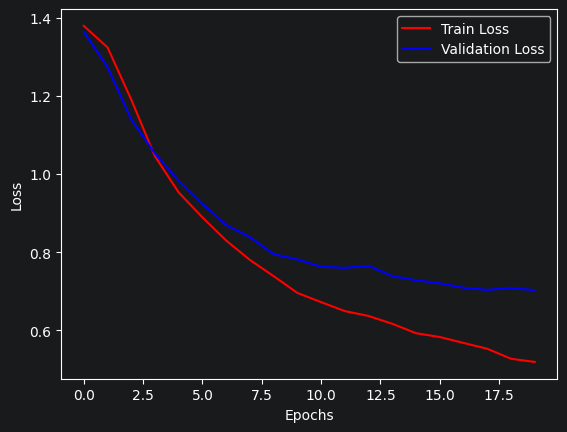


 ===================== Training Fold 3  ===================== 

Saved new best model to Models/Classifier/fold_3.pth, with new best_val_loss=1.360262781381607
Saved new best model to Models/Classifier/fold_3.pth, with new best_val_loss=1.2749629318714142
Saved new best model to Models/Classifier/fold_3.pth, with new best_val_loss=1.120828002691269
Saved new best model to Models/Classifier/fold_3.pth, with new best_val_loss=0.9821523427963257
Saved new best model to Models/Classifier/fold_3.pth, with new best_val_loss=0.870812714099884
Saved new best model to Models/Classifier/fold_3.pth, with new best_val_loss=0.8126058429479599
Saved new best model to Models/Classifier/fold_3.pth, with new best_val_loss=0.7876796126365662
Saved new best model to Models/Classifier/fold_3.pth, with new best_val_loss=0.7475753128528595
Saved new best model to Models/Classifier/fold_3.pth, with new best_val_loss=0.7456154525279999
Saved new best model to Models/Classifier/fold_3.pth, with new best_val_lo

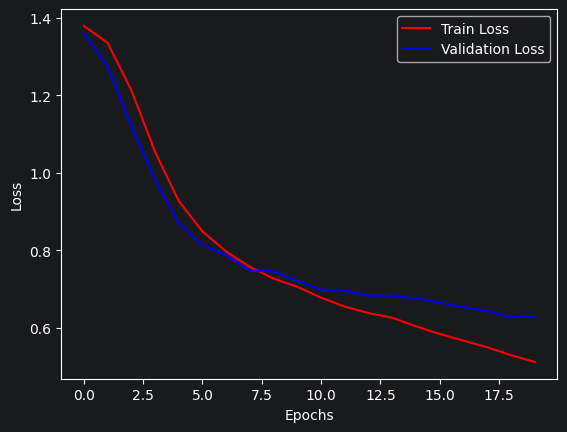


 ===================== Training Fold 4  ===================== 

Saved new best model to Models/Classifier/fold_4.pth, with new best_val_loss=1.3656886518001556
Saved new best model to Models/Classifier/fold_4.pth, with new best_val_loss=1.3117906153202057
Saved new best model to Models/Classifier/fold_4.pth, with new best_val_loss=1.1833212077617645
Saved new best model to Models/Classifier/fold_4.pth, with new best_val_loss=1.062970131635666
Saved new best model to Models/Classifier/fold_4.pth, with new best_val_loss=0.981823742389679
Saved new best model to Models/Classifier/fold_4.pth, with new best_val_loss=0.8996853679418564
Saved new best model to Models/Classifier/fold_4.pth, with new best_val_loss=0.8517426699399948
Saved new best model to Models/Classifier/fold_4.pth, with new best_val_loss=0.7879079282283783
Saved new best model to Models/Classifier/fold_4.pth, with new best_val_loss=0.7582026422023773
Saved new best model to Models/Classifier/fold_4.pth, with new best_val_l

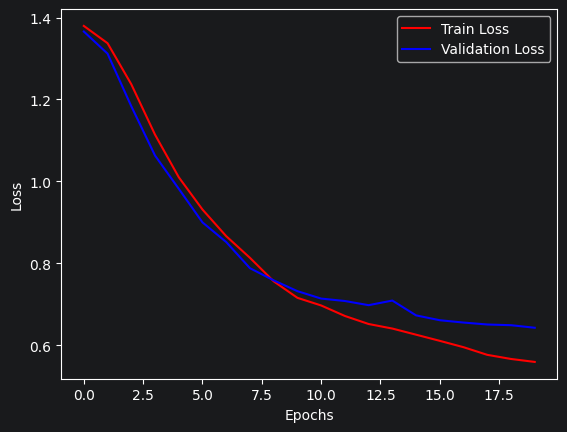

In [18]:
import numpy as np
from sklearn.model_selection import KFold
from torch.utils.data import TensorDataset
import matplotlib.pyplot as plt
import os

#paths
write_model_dir = os.path.join('Models', 'Classifier')
os.makedirs(write_model_dir, exist_ok=True)


# Hyperparameter
batch_size = 256
learning_rate = 1e-3 #https://x.com/karpathy/status/801621764144971776?lang=en
n_epochs = 20

# Model Parameters
model_parameter = {
    'n_hidden': 3,
    'hidden_dim': 64,
    'input_dim':X_train_val.shape[1],
    'output_dim':len(np.unique(y_train_val))
}

# Dataset
trainval_set = TensorDataset(X_train_val, y_train_val)

kf = KFold(n_splits=5, shuffle=True, random_state=42)
for fold, (train_idx, val_idx) in enumerate(kf.split(range(len(trainval_set)))):
    print(f'\n ===================== Training Fold {fold}  ===================== \n')


    # Loaders
    train_loader, val_loader = get_train_loaders(
        dataset=trainval_set,
        train_idx=train_idx,
        val_idx=val_idx,
        batch_size=batch_size,
    )

    # Model, Optimizer, Criterion
    model = MLPClassifier(**model_parameter).to(DEVICE)
    Optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    criterion = torch.nn.CrossEntropyLoss()

    best_val_loss = float('inf')
    history = {
        'train_loss': [],
        'val_loss': [],
    }

    for epoch in range(n_epochs):
        train_loss = _train_one_epoch(model, train_loader, Optimizer, criterion)
        val_loss = _calculate_val_loss(model, val_loader, criterion)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)

        if best_val_loss > val_loss:
            best_val_loss = val_loss
            model_path = os.path.join(write_model_dir, f"fold_{fold}.pth")
            torch.save(model.state_dict(), model_path)
            print(f'Saved new best model to {model_path}, with new {best_val_loss=}')

    plt.plot(history['train_loss'], label='Train Loss', color='red')
    plt.plot(history['val_loss'], label='Validation Loss', color='blue')
    plt.grid(False)
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

# Model Wrapping, Prediction function and Test Set Metrics

In [20]:
MODELS_DIR = os.path.join('Models', 'Classifier')
fold_paths = [os.path.join(MODELS_DIR, f) for f in os.listdir(MODELS_DIR)]

# Model Parameters
model_parameter = {
    'n_hidden': 3,
    'hidden_dim': 64,
    'input_dim':X_train_val.shape[1],
    'output_dim':len(np.unique(y_train_val))
    }

clf_ensamble = []
for path in fold_paths:
    m = MLPClassifier(**model_parameter)
    m.load_state_dict(torch.load(path))
    clf_ensamble.append(MyWrapper(m, np.unique(y_train_val)))

clf_ensamble

[MyWrapper(classes=array([0, 1, 2, 3]), device=device(type='cuda'),
           model=MLPClassifier(
   (input_layer): Linear(in_features=20, out_features=64, bias=True)
   (hidden_layers): ModuleList(
     (0-2): 3 x Linear(in_features=64, out_features=64, bias=True)
   )
   (output_layer): Linear(in_features=64, out_features=4, bias=True)
   (activation): ReLU()
 )),
 MyWrapper(classes=array([0, 1, 2, 3]), device=device(type='cuda'),
           model=MLPClassifier(
   (input_layer): Linear(in_features=20, out_features=64, bias=True)
   (hidden_layers): ModuleList(
     (0-2): 3 x Linear(in_features=64, out_features=64, bias=True)
   )
   (output_layer): Linear(in_features=64, out_features=4, bias=True)
   (activation): ReLU()
 )),
 MyWrapper(classes=array([0, 1, 2, 3]), device=device(type='cuda'),
           model=MLPClassifier(
   (input_layer): Linear(in_features=20, out_features=64, bias=True)
   (hidden_layers): ModuleList(
     (0-2): 3 x Linear(in_features=64, out_features=64, b

## Prediction Function and Test Set Evaluation

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, RocCurveDisplay, classification_report, confusion_matrix
import numpy as np
import warnings

# Suppress all FutureWarnings
warnings.filterwarnings("ignore")


def mean_response():
    #TODO: Implement Mean Response Function
    pass

def report(target:np.ndarray, y_proba:np.ndarray, y_pred:np.ndarray, classes:list):
    fig, ax = plt.subplots(1,2, figsize=(20, 6))
    ax = ax.flatten()

    cf_mtx = confusion_matrix(target, y_pred)
    sns.heatmap(cf_mtx, annot=True, fmt="g", ax=ax[0])
    ax[0].set_title('Confusion Matrix')

    for idx in range(len(classes)):
        fpr, tpr, thresholds = roc_curve(target == idx, y_proba[:, idx])
        roc_auc = auc(fpr, tpr)
        display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc)
        display.plot(ax=ax[1])

    ax[1].plot([0, 1], [0, 1], color='white', linestyle='--')
    ax[1].set_title('Multiclass ROC Curve (One-vs-Rest)')


    ax[0].set_xticklabels(classes)
    ax[0].set_yticklabels(classes)
    plt.legend(classes)
    plt.show()

    clf_r = classification_report(target, y_pred)
    print(clf_r)